# AI 4 Life Science - Unsupervised Representation Learning - Tutorial 1: Introduction and VAEs

## Setup and Groups

Form groups of 3, ideally with people you do not work with regularly. Take 5 min each to explain a bit about your work:

1. What is the focus of your work?

2. What is the limitation or most difficult technical aspect?

3. Could unsupervised learning fit into your project in any way? If so, where could it improve things. If not, why is it unhelpful and what do you wish it could do?


To explore unsupervised learning with code, you can either set up this notebook on your university/lab computer, run it locally, or import it to colab. If you wish to run locally, but do not have anything set up on your machine, we recommend uv for a quick and easy setup:  
https://docs.astral.sh/uv/getting-started/installation/  
After installing uv, you can start a project: https://docs.astral.sh/uv/guides/projects/  
and start up the jupyter notebook with this guide: https://docs.astral.sh/uv/guides/integration/jupyter/  
We will include uv package installation commands throughout (as suggestions), but you are of course free to use your existing environments or preferred packages.

# Data

If you have your own imaging data, setup a data loader or manually load a handful of samples. Ideally choose data that you can compare, e.g. a few different classes or segmentations etc.

If you do not have your own imaging data, you can consider using synthetic test data we have created (or create your own!).  
Our data is hosted at: https://huggingface.co/datasets/Jemtan11/AADD   
And the abdominal test data (recommended) can be found here: https://huggingface.co/datasets/Jemtan11/AADD/tree/main/abdom/test  
Navigate to the different test classes and download one sample per class.

**Alternatively** you can skip down to the model section and select a public dataset associated with that model.

In [ ]:
!uv add nibabel
!uv add matplotlib
!uv add torch torchvision

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import nibabel as nib
import torch

In [29]:
file_path = 'data/class0/aadd_00001.nii.gz'#or wherever you have put your samples
img = nib.load(file_path)
img = nib.as_closest_canonical(img)
img_data = torch.from_numpy(img.get_fdata())
img_data_r = torch.movedim(img_data,1,0).rot90(dims=(-2,-1))

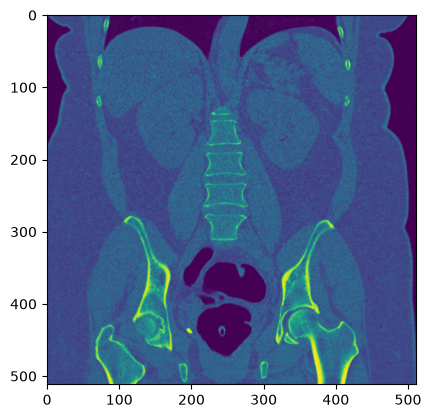

In [30]:
plt.imshow(img_data_r[200])

# Model

To save time and compute, we suggest finding a pre-trained VAE, perhaps one of the following:  
https://github.com/NVIDIA-Medtech/NV-Generate-CTMR/blob/main/train_vae_tutorial.ipynb  
https://huggingface.co/stanfordmimi/MedVAE  
https://github.com/MIC-DKFZ/nnssl  (This is MAE instead of VAE but we will cover that later)   
https://github.com/lzl199704/vis-mae (MAE again)  
or find one more suitable for your type of data. You could also try training your own VAE from scratch on small images, e.g. MedMNIST data (https://medmnist.com/)  

Adjust your data to match the input format of your chosen model as best as you can. You can also consider downloading a portion of their training datasets to play with.

Consider:
1. How is the quality of the reconstructions? 
2. What aspects are missing? What aspects are reproduced faithully?
3. For the same input, generate multiple samples. How do the reconstructions differ?
4. Generate random samples from the prior distribution. How do they differ from your data?
5. Modify the latent space around a sample in a few random directions. How do the samples differ?
6. Are any of these variations relevant for your type of task?


# Analysis

Taking samples from different classes, use the encoder to get the corresponding latent codes (or samples from the predicted distribution). Use a t-SNE or UMAP package to plot your latent codes, colour-coded by class.

In [ ]:
!uv add openTSNE
!uv add umap-learn

1. Is the VAE encoder useful in distinguishing your classes?
2. Does it provide a major advantage over distinguishing your classes in image space?